## Bases de datos

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

datos=pd.read_csv('base_suelos.csv')
datos=datos[:2000]
datos

,CO,CIC
0,1.2,6.5
1,1.4,12.0
2,3.5,22.5
3,1.4,6.8
4,2.7,7.8
...,...,...
1995,0.2,14.5
1996,0.3,5.3
1997,0.5,18.8
1998,0.3,12.5


## Paso 1.Determinación de las distribuciones marginales asociadas a cada una de las variables en función de las muestras de datos disponibles.

Se usa KDE (Kernel Density Estimation)
1. Estima la distribución de probabilidad de los rendimientos usando kernels gaussianos.
2. En lugar de asumir una distribución normal, se adapta a la forma real de los datos

In [ ]:
from scipy.integrate import quad
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
def compute_empirical_cdf(kde, x_values):
    """
    Calcular CDF empírica
    """
    cdf_values = np.zeros_like(x_values)

    for i, x in enumerate(x_values):
        result, _ = quad(kde, -np.inf, x) # Integrar la KDE desde -infinito hasta x
        cdf_values[i] = result

    return cdf_values

def transform_to_uniform(returns_series):
    """
    Transformar realizaciones de X a variables uniformes U
    """
    returns = returns_series.dropna().values

    # Estimar KDE
    kde = stats.gaussian_kde(returns)

    # Calcular CDF empírica para cada observación
    uniform_transformed = np.array([quad(kde, -np.inf, x)[0] for x in returns])

    return uniform_transformed
uniform_data = {}
for idx in datos[['CO','CIC']].columns:
    uniform_data[idx] = transform_to_uniform(datos[idx])

uniform_df = pd.DataFrame(uniform_data)

In [ ]:
f_x=uniform_df['CO']
g_y=uniform_df['CIC']

In [ ]:
uniform_df.describe()

,CO,CIC
count,2000.000000,2000.000000
mean,0.500000,0.496512
std,0.275172,0.230197
min,0.067397,0.001750
25%,0.253672,0.300343
50%,0.482299,0.469705
75%,0.745212,0.674398
max,0.999750,0.994526


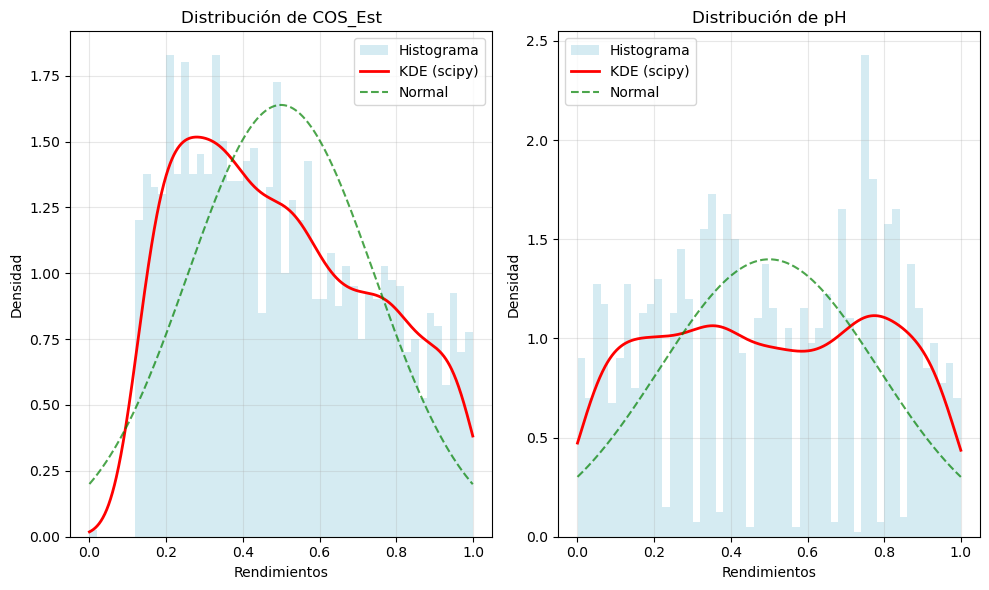

In [ ]:
import seaborn as sns
from scipy import stats
from sklearn.neighbors import KernelDensity
import matplotlib.pyplot as plt
def plot_kde_scipy(data_df, indices=None):
    if indices is None:
        indices = ['CO','CIC']

    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        if i >= len(axes):
            break

        dat = data_df[idx].dropna()
        kde = stats.gaussian_kde(dat)# Estimación KDE con scipy
        x_range = np.linspace(dat.min(), dat.max(), 1000)
        kde_values = kde.evaluate(x_range)
        axes[i].hist(dat, bins=50, density=True, alpha=0.5,
                    color='lightblue', label='Histograma')
        axes[i].plot(x_range, kde_values, 'r-', linewidth=2,
                    label='KDE (scipy)')


        mu, sigma = dat.mean(), dat.std() # Comparar con distribución normal
        normal_pdf = stats.norm.pdf(x_range, mu, sigma)
        axes[i].plot(x_range, normal_pdf, 'g--', alpha=0.7,
                    label='Normal')

        axes[i].set_title(f'Distribución de {idx}')
        axes[i].set_xlabel('Rendimientos')
        axes[i].set_ylabel('Densidad')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
plot_kde_scipy(uniform_df)

## 2.Pruebas Gráficas y Teóricas de Dependencia.

In [ ]:
uniform_df.corr(method='spearman') ## usa pearson por defecto, se puede cambiar dependniendo de los datos
## method='kendall' para tau de kendall
## method='spearman'

,CO,CIC
CO,1.000000,0.445798
CIC,0.445798,1.000000


array([[<Axes: xlabel='CO', ylabel='CO'>,
        <Axes: xlabel='CIC', ylabel='CO'>],
       [<Axes: xlabel='CO', ylabel='CIC'>,
        <Axes: xlabel='CIC', ylabel='CIC'>]], dtype=object)

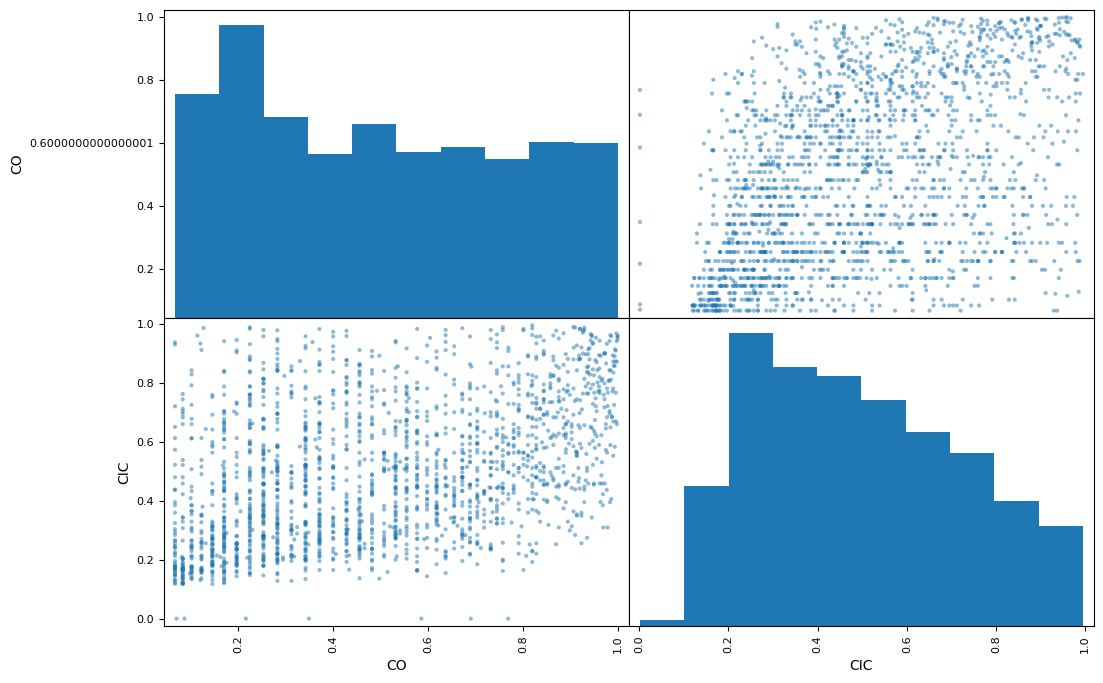

In [ ]:
pd.plotting.scatter_matrix(uniform_df, figsize=(12, 8))

##3. Elegir una familia de cópulas.

Clayton.\
Fuerte dependencia en colas inferiores: Captura cuando las variables tienden a moverse juntas en valores bajos.\
\
Gumbel.\
Fuerte dependencia en colas superiores: Captura cuando las variables tienden a moverse juntas en valores altos

In [ ]:
def copula_empirica(u, v):
    """
    Calcula la cópula empírica bivariada usando el enfoque de rango
    C_n(u,v) = (1/(n+1)) * Σ I(U_i ≤ u, V_i ≤ v)
    """
    n = len(u)
    C_emp = np.zeros(n)

    for i in range(n):
        C_emp[i] = np.sum((u <= u[i]) & (v <= v[i])) / (n + 1)

    return C_emp

def transformar_a_copula_empirica(returns_series1, returns_series2):
    """
    Transforma los rendimientos a cópula empírica usando rangos
    """
    data = pd.DataFrame({
        'x': returns_series1.dropna(),
        'y': returns_series2.dropna()
    }).dropna()

    n = len(data)
    data['rank_x'] = data['x'].rank() / (n + 1)
    data['rank_y'] = data['y'].rank() / (n + 1)

    return data['rank_x'].values, data['rank_y'].values

In [ ]:
u,v=transformar_a_copula_empirica(datos['CO'],datos['CIC'])

## Estimar los parámetros (Calibración) y evaluar el ajuste

In [ ]:
import sympy as sp
import numpy as np
from scipy.optimize import minimize
from scipy import stats
import pandas as pd
def estimar_parametros_copula(u, v):
    u_sym, v_sym, theta_sym = sp.symbols('u v theta', real=True)

    resultados = []

    # Copula de Clayton
    C_clayton = (u_sym**(-theta_sym) + v_sym**(-theta_sym) - 1)**(-1/theta_sym)
    densidad_clayton = sp.diff(sp.diff(C_clayton, u_sym), v_sym)
    densidad_clayton_simp = sp.simplify(densidad_clayton)
    densidad_clayton_func = sp.lambdify((u_sym, v_sym, theta_sym), densidad_clayton_simp, 'numpy')
    C_clayton_func = sp.lambdify((u_sym, v_sym, theta_sym), C_clayton, 'numpy')

    # Copula de Gumbel
    a = (-sp.log(u_sym))**theta_sym
    b = (-sp.log(v_sym))**theta_sym
    C_gumbel = sp.exp(-(a + b)**(1/theta_sym))
    densidad_gumbel = sp.diff(sp.diff(C_gumbel, u_sym), v_sym)
    densidad_gumbel_simp = sp.simplify(densidad_gumbel)
    densidad_gumbel_func = sp.lambdify((u_sym, v_sym, theta_sym), densidad_gumbel_simp, 'numpy')
    C_gumbel_func = sp.lambdify((u_sym, v_sym, theta_sym), C_gumbel, 'numpy')

    # Copula de Frank
    C_frank = -1/theta_sym * sp.log(1 + ((sp.exp(-theta_sym * u_sym) - 1) * (sp.exp(-theta_sym * v_sym) - 1)) / (sp.exp(-theta_sym) - 1))
    densidad_frank = sp.diff(sp.diff(C_frank, u_sym), v_sym)
    densidad_frank_simp = sp.simplify(densidad_frank)
    densidad_frank_func = sp.lambdify((u_sym, v_sym, theta_sym), densidad_frank_simp, 'numpy')
    C_frank_func = sp.lambdify((u_sym, v_sym, theta_sym), C_frank, 'numpy')

    # Funciones de verosimilitud
    def verosimilitud_clayton(theta): #θ[0,inf] sin 0
        if theta <= 0:
            return 1e10
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_clayton_func(u[i], v[i], theta)
                if dens > 0:
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) and not np.isinf(-log_lik) else 1e10

    def verosimilitud_gumbel(theta): #θ[1,inf]
        if theta < 1:
            return 1e10
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_gumbel_func(u[i], v[i], theta)
                if dens > 0 and not np.isnan(dens):
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) and not np.isinf(-log_lik) else 1e10

    def verosimilitud_frank(theta): #θ ∈ ℝ \ {0}
        if theta == 0:
            return 1e10
        log_lik = 0
        for i in range(len(u)):
            try:
                dens = densidad_frank_func(u[i], v[i], theta)
                if dens > 0 and not np.isnan(dens) and not np.isinf(dens):
                    log_lik += np.log(dens)
            except:
                continue
        return -log_lik if not np.isnan(-log_lik) and not np.isinf(-log_lik) else 1e10
    try:
        resultado_clayton = minimize(verosimilitud_clayton, [1.0], method='L-BFGS-B', bounds=[(0.001, 20)])
        param_clayton = resultado_clayton.x[0]
        loglik_clayton = -resultado_clayton.fun
    except:
        param_clayton = np.nan
        loglik_clayton = -np.inf

    try:
        resultado_gumbel = minimize(verosimilitud_gumbel, [2.0], method='L-BFGS-B', bounds=[(1.001, 20)])
        param_gumbel = resultado_gumbel.x[0]
        loglik_gumbel = -resultado_gumbel.fun
    except:
        param_gumbel = np.nan
        loglik_gumbel = -np.inf

    try:
        # Para Frank, probamos diferentes valores iniciales ya que puede ser positivo o negativo
        resultado_frank1 = minimize(verosimilitud_frank, [2.0], method='L-BFGS-B', bounds=[(0.001, 20)])
        resultado_frank2 = minimize(verosimilitud_frank, [-2.0], method='L-BFGS-B', bounds=[(-20, -0.001)])

        if resultado_frank1.fun < resultado_frank2.fun:
            param_frank = resultado_frank1.x[0]
            loglik_frank = -resultado_frank1.fun
        else:
            param_frank = resultado_frank2.x[0]
            loglik_frank = -resultado_frank2.fun
    except:
        param_frank = np.nan
        loglik_frank = -np.inf

    # Pruebas de bondad de ajuste AD y IAD
    def prueba_ad_copula(u, v, copula_func, theta):
        n = len(u)
        C_emp = copula_empirica(u, v)
        try:
            C_teo = np.array([copula_func(u[i], v[i], theta) for i in range(n)])
            indices_ordenados = np.argsort(C_teo)
            C_teo_sorted = C_teo[indices_ordenados]
            C_emp_sorted = C_emp[indices_ordenados]

            i = np.arange(1, n + 1)
            ad_stat = -n - np.sum((2*i - 1) * (np.log(C_teo_sorted) + np.log(1 - C_emp_sorted[::-1]))) / n
            return ad_stat
        except:
            return np.inf

    def prueba_iad_copula(u, v, copula_func, theta):
        n = len(u)
        C_emp = copula_empirica(u, v)
        try:
            C_teo = np.array([copula_func(u[i], v[i], theta) for i in range(n)])
            iad_stat = np.sum((C_teo - C_emp)**2)
            return iad_stat
        except:
            return np.inf
    if not np.isnan(param_clayton):
        ad_clayton = prueba_ad_copula(u, v, C_clayton_func, param_clayton)
        iad_clayton = prueba_iad_copula(u, v, C_clayton_func, param_clayton)
    else:
        ad_clayton, iad_clayton = np.inf, np.inf

    if not np.isnan(param_gumbel):
        ad_gumbel = prueba_ad_copula(u, v, C_gumbel_func, param_gumbel)
        iad_gumbel = prueba_iad_copula(u, v, C_gumbel_func, param_gumbel)
    else:
        ad_gumbel, iad_gumbel = np.inf, np.inf

    if not np.isnan(param_frank):
        ad_frank = prueba_ad_copula(u, v, C_frank_func, param_frank)
        iad_frank = prueba_iad_copula(u, v, C_frank_func, param_frank)
    else:
        ad_frank, iad_frank = np.inf, np.inf
    resultados = [
        {'Cópula': 'Clayton', 'Parámetro': param_clayton, 'Log-Lik': loglik_clayton,
         'AD': ad_clayton, 'IAD': iad_clayton},
        {'Cópula': 'Gumbel', 'Parámetro': param_gumbel, 'Log-Lik': loglik_gumbel,
         'AD': ad_gumbel, 'IAD': iad_gumbel},
        {'Cópula': 'Frank', 'Parámetro': param_frank, 'Log-Lik': loglik_frank,
         'AD': ad_frank, 'IAD': iad_frank}
    ]

    tabla = pd.DataFrame(resultados)
    tabla = tabla.sort_values('Log-Lik', ascending=False)

    return tabla, densidad_clayton_simp, densidad_gumbel_simp, densidad_frank_simp


In [ ]:
tabla_resultados, dens_clayton, dens_gumbel, dens_frank= estimar_parametros_copula(f_x, g_y)
tabla_resultados

,Cópula,Parámetro,Log-Lik,AD,IAD
0,Clayton,1.342289,272.283979,297.884367,4.825880
2,Frank,3.769593,220.579958,320.508403,2.793717
1,Gumbel,1.461663,169.493341,391.062050,2.356857


## Simular cópula.

In [ ]:
def copula_Cook_Jonhson(n, theta):
    """
    1. simular u,q ~U[0,1]
    2. compute v = C^{-1}(q|u) = ([q^{-theta/(1+theta)} - 1] * u^{-theta} + 1)^{-1/theta}
    3. Generar pares (u,v)
    """
    u = np.random.uniform(0, 1, n)
    q = np.random.uniform(0, 1, n)
    v = ((q**(-theta/(1 + theta)) - 1) * u**(-theta) + 1)**(-1/theta)

    return u,v


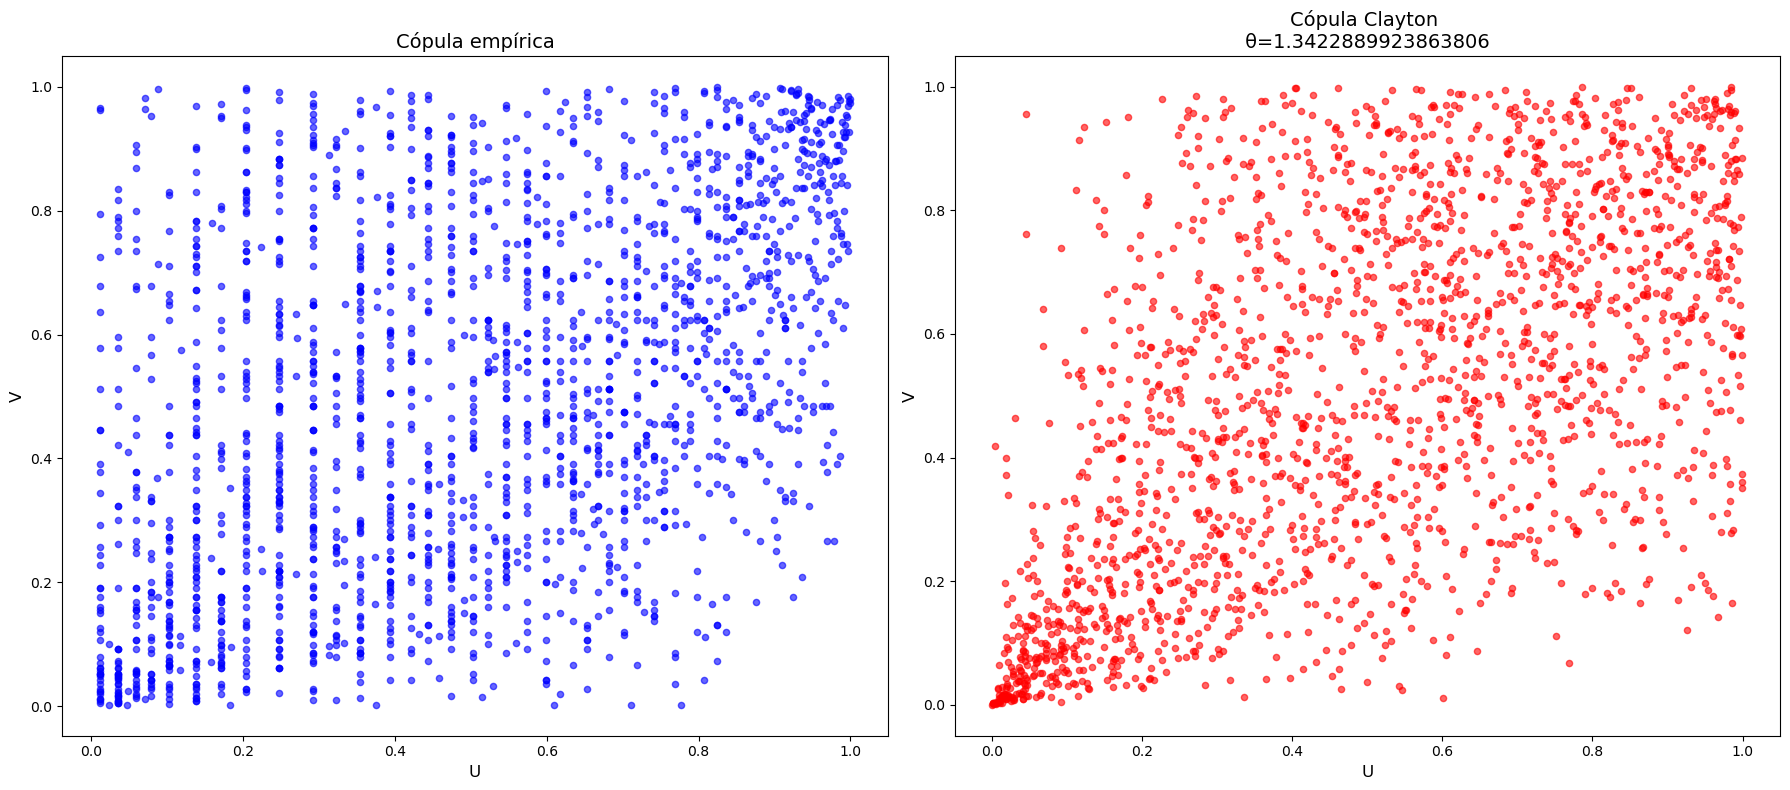

In [ ]:
plt.figure(figsize=(18, 8))
plt.subplot(1, 2, 1)
plt.scatter(u, v, alpha=0.6, s=20, color='blue')
plt.xlabel('U', fontsize=12)
plt.ylabel('V', fontsize=12)
plt.title('Cópula empírica', fontsize=14)

plt.subplot(1, 2, 2)
a,b=copula_Cook_Jonhson(len(datos), tabla_resultados.Parámetro[0])
plt.scatter(a, b, alpha=0.6, s=20, color='red')
plt.xlabel('U', fontsize=12)
plt.ylabel('V', fontsize=12)
plt.title(f'Cópula Clayton \n θ={tabla_resultados.Parámetro[0]} ', fontsize=14)


plt.tight_layout()
plt.show()